# **Mission of the regression notebook**

You have joined a space-biology team studying how the model plant [*Arabidopsis thaliana*](https://en.wikipedia.org/wiki/Arabidopsis_thaliana) adapts to life aboard the [International Space Station](https://www.nasa.gov/international-space-station/).  Your team is trying to find the [biological pathways](https://en.wikipedia.org/wiki/Biological_pathway) that respond to adverse conditions in space such as [microgravity](https://www.nasa.gov/centers-and-facilities/glenn/what-is-microgravity/) and [radiation](https://www.nasa.gov/directorates/esdmd/hhp/space-radiation/).  Your data come from the **CARA experiment** (*Characterizing Arabidopsis Root Attributes*, [OSD-120](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120)), which compared the roots of spaceflight (FLT) plants grown on the ISS against ground control (GC) plants on Earth.  You just performed clustering on the RNA-seq data and found a noticeable separation between spaceflight and ground control gene expression profiles, giving you confidence that there is a signal that machine learning could exploit.  You also have a table of root phenotype measurements (root length), so you can now perform supervised learning with your data.

Your mission is to use supervised machine learning - [regression](https://en.wikipedia.org/wiki/Regression_analysis) - to determine if the RNA-seq data from spaceflight roots and their ground control counterparts have clearly distinguishable gene expression profiles.  For if they do, then there is a chance that a supervised learning method can predict root responses to spaceflight using different combinations and weights of gene expression from the RNA-seq data.

In this notebook, you will use linear regression to predict the value of a root phenotype response (root length) given its associated RNA-seq gene expression profile.

# Set up and read in the data

This notebook is self-contained: it loads real CARA (OSD-120) *Arabidopsis* root data directly from the NASA OSDR repository over the internet, plus a local root-phenotype table.  Run the cells in order.  We will use [pandas](https://pandas.pydata.org/) and [NumPy](https://numpy.org/) for the data and [scikit-learn](https://scikit-learn.org/) for the regression models.

In [1]:
# import the libraries we will use throughout this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import islice

from sklearn.linear_model import LinearRegression, Ridge, TweedieRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# OSDR (OSD-120 / CARA) download URLs for the Arabidopsis root RNA-seq data
NORM_COUNTS_URL = ("https://osdr.nasa.gov/geode-py/ws/studies/OSD-120/download"
                   "?source=datamanager&file=GLDS-120_rna_seq_Normalized_Counts_GLbulkRNAseq.csv")
DE_TABLE_URL = ("https://osdr.nasa.gov/geode-py/ws/studies/OSD-120/download"
                "?source=datamanager&file=GLDS-120_rna_seq_differential_expression_GLbulkRNAseq.csv")

In [3]:
# Helper functions for this notebook (replacing the old shared "methods" module).

# A gene-ID -> gene-symbol lookup built from the OSDR differential-expression table.
# Arabidopsis genes are named by their AGI locus code (e.g. AT1G01010).
_de_table = pd.read_csv(DE_TABLE_URL, index_col=0, low_memory=False)
_symbol_map = _de_table['SYMBOL'].to_dict()

def get_symbol_from_id(gene_ids):
    """Return the Arabidopsis gene symbol(s) for one or more AGI locus IDs."""
    return [_symbol_map.get(g, g) for g in gene_ids]

def parse_sample(col):
    """Parse an OSD-120 sample column name into (ecotype, treatment, illumination).

    Column names look like:
      Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13
    """
    parts = col.split('_')
    return (parts[1], parts[3], parts[4])  # ecotype, GC/FLT, Alight/dark

In [4]:
# read in the normalized RNA-seq counts (genes x samples) from OSDR
counts = pd.read_csv(NORM_COUNTS_URL, index_col=0)
print('rna-seq counts shape (genes x samples):', counts.shape)
counts.head()

rna-seq counts shape (genes x samples): (24740, 36)


,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
AT1G01010,114.904131,138.527368,120.022494,264.937105,191.422936,242.517040,412.253673,210.840135,144.668736,201.744019,...,424.847210,147.983322,277.194348,115.874562,309.806447,320.963807,398.109857,104.633344,85.672000,105.632330
AT1G01020,673.515535,621.793455,645.936090,439.201986,522.399305,748.214534,537.977432,739.297948,656.648675,627.933477,...,463.448392,713.731341,961.798409,496.336366,569.696041,454.003757,581.384441,749.912117,688.502249,559.374814
AT1G01030,94.043792,94.223868,65.271628,103.706224,86.287958,103.357911,189.930809,141.967726,81.612611,110.981125,...,49.957938,80.945443,161.394188,43.761590,105.958171,136.696201,96.310749,182.954416,249.215970,123.892672
AT1G01040,164.879084,94.035143,238.621873,132.559195,182.120176,175.679477,205.565473,131.052912,171.811433,134.112724,...,83.333634,156.572361,101.033035,234.971130,209.744502,350.823340,155.615105,161.055119,189.724432,108.131266
AT1G01046,0.000000,0.000000,0.000000,0.000000,5.052491,0.000000,2.427154,0.000000,0.829751,0.000000,...,1.393093,0.000000,0.000000,0.000000,0.000000,0.000000,0.988599,0.000000,0.000000,1.004718


# Read in the data

In this section, we read in the CARA *Arabidopsis* root data.  We will use:

* the **normalized RNA-seq counts** (24,740 genes across 36 root samples) from OSD-120, and
* a local **root phenotype table** (`CARA_Root_RSML_exported_data_day11.csv`) that contains the measured **root length** (in cm) for spaceflight (FLT) and ground control (GC) roots.

We will build a continuous root-length target for each RNA-seq sample by matching each sample's experimental group (ecotype x spaceflight treatment x illumination) to the mean measured root length of that same group.

In [5]:
# read in the local CARA root phenotype table and compute the mean root length per group
phenotype = pd.read_csv('CARA_Root_RSML_exported_data_day11.csv')

# normalize the phenotype labels so they match the RNA-seq sample naming
_eco_map = {'Col': 'Col-0', 'WS': 'Ws', 'Phy': 'Col-0-PhyD', 'PhyD': 'Col-0-PhyD'}
phenotype['ecotype'] = phenotype['Ecotype/Genotype'].map(lambda x: _eco_map.get(str(x), str(x)))
phenotype['treatment'] = phenotype['Spaceflight Treatment'].map({'Fl': 'FLT', 'Gr': 'GC'})
phenotype['illumination'] = phenotype['Illumination trestment 2'].map({'Dark': 'dark', 'Light': 'Alight'})

# mean root length (cm) for each (ecotype, treatment, illumination) group
group_length = phenotype.groupby(['ecotype', 'treatment', 'illumination'])['length'].mean().to_dict()
print('phenotype table shape:', phenotype.shape)
phenotype[['Image Name', 'length', 'ecotype', 'treatment', 'illumination']].head()

phenotype table shape: (177, 16)


,Image Name,length,ecotype,treatment,illumination
0,Fl_Dark_Plate1_WS_day11.rsml,3.035,Ws,FLT,dark
1,Fl_Dark_Plate1_WS_day11.rsml,3.056,Ws,FLT,dark
2,Fl_Dark_Plate1_WS_day11.rsml,5.079,Ws,FLT,dark
3,Fl_Dark_Plate1_WS_day11.rsml,4.237,Ws,FLT,dark
4,Fl_Dark_Plate1_WS_day11.rsml,3.734,Ws,FLT,dark


In [6]:
# show the mean measured root length (cm) for each experimental group
for k, v in sorted(group_length.items()):
    print(k, '-> mean root length: %.3f cm' % v)

('Col-0', 'FLT', 'Alight') -> mean root length: 2.382 cm
('Col-0', 'FLT', 'dark') -> mean root length: 3.604 cm
('Col-0', 'GC', 'Alight') -> mean root length: 3.145 cm
('Col-0', 'GC', 'dark') -> mean root length: 3.576 cm
('Col-0-PhyD', 'FLT', 'Alight') -> mean root length: 3.169 cm
('Col-0-PhyD', 'FLT', 'dark') -> mean root length: 3.087 cm
('Col-0-PhyD', 'GC', 'Alight') -> mean root length: 3.290 cm
('Col-0-PhyD', 'GC', 'dark') -> mean root length: 3.630 cm
('Ws', 'FLT', 'Alight') -> mean root length: 3.378 cm
('Ws', 'FLT', 'dark') -> mean root length: 3.401 cm
('Ws', 'GC', 'Alight') -> mean root length: 3.700 cm
('Ws', 'GC', 'dark') -> mean root length: 3.784 cm


In [7]:
# build the regression target y: the mean root length for each RNA-seq sample's group
y = []
matched_samples = []
for col in counts.columns:
    key = parse_sample(col)            # (ecotype, GC/FLT, Alight/dark)
    if key in group_length:
        y.append(group_length[key])
        matched_samples.append(col)
y = np.array(y)
print('number of RNA-seq samples matched to a root-length value:', len(matched_samples))
print('root-length target values (cm):')
print(np.round(y, 3))

number of RNA-seq samples matched to a root-length value: 36
root-length target values (cm):
[3.145 3.145 3.7   3.7   3.7   3.29  3.29  3.29  3.576 3.576 3.576 3.784
 3.784 3.784 3.63  3.63  3.63  2.382 2.382 2.382 3.378 3.378 3.378 3.169
 3.169 3.169 3.604 3.604 3.604 3.401 3.401 3.401 3.087 3.087 3.087 3.145]


In [8]:
# look at the RNA-seq normalized counts again (genes are rows, root samples are columns)
print('rna-seq data shape:', counts.shape)
counts.head()

rna-seq data shape: (24740, 36)


,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
AT1G01010,114.904131,138.527368,120.022494,264.937105,191.422936,242.517040,412.253673,210.840135,144.668736,201.744019,...,424.847210,147.983322,277.194348,115.874562,309.806447,320.963807,398.109857,104.633344,85.672000,105.632330
AT1G01020,673.515535,621.793455,645.936090,439.201986,522.399305,748.214534,537.977432,739.297948,656.648675,627.933477,...,463.448392,713.731341,961.798409,496.336366,569.696041,454.003757,581.384441,749.912117,688.502249,559.374814
AT1G01030,94.043792,94.223868,65.271628,103.706224,86.287958,103.357911,189.930809,141.967726,81.612611,110.981125,...,49.957938,80.945443,161.394188,43.761590,105.958171,136.696201,96.310749,182.954416,249.215970,123.892672
AT1G01040,164.879084,94.035143,238.621873,132.559195,182.120176,175.679477,205.565473,131.052912,171.811433,134.112724,...,83.333634,156.572361,101.033035,234.971130,209.744502,350.823340,155.615105,161.055119,189.724432,108.131266
AT1G01046,0.000000,0.000000,0.000000,0.000000,5.052491,0.000000,2.427154,0.000000,0.829751,0.000000,...,1.393093,0.000000,0.000000,0.000000,0.000000,0.000000,0.988599,0.000000,0.000000,1.004718


In [9]:
# a quick look at the spread of root length across all measured roots
print('root length summary (cm):')
phenotype['length'].describe()

root length summary (cm):


count    177.000000
mean       3.333616
std        0.736176
min        1.201000
25%        2.971000
50%        3.349000
75%        3.784000
max        5.754000
Name: length, dtype: float64

# Use linear regression to predict root phenotype from RNA-seq

In this section, we will use linear regression to predict **root length** from gene expression.  Each RNA-seq root sample is assigned the mean root length of its experimental group (ecotype x spaceflight treatment x illumination), so that every sample has both a gene-expression profile (our inputs, `X`) and a continuous phenotype value (our target, `y`).

## Use linear regression to predict root length from gene expression data

In [10]:
# we have already matched every RNA-seq sample to a root-length value above.
# Confirm how many samples we will use and which experimental groups they cover.
print('samples used:', len(matched_samples))
group_summary = pd.DataFrame({
    'sample': matched_samples,
    'ecotype': [parse_sample(c)[0] for c in matched_samples],
    'treatment': [parse_sample(c)[1] for c in matched_samples],
    'illumination': [parse_sample(c)[2] for c in matched_samples],
    'root_length': y,
})
group_summary.head()

samples used: 36


,sample,ecotype,treatment,illumination,root_length
0,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Col-0,GC,Alight,3.145364
1,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Col-0,GC,Alight,3.145364
2,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Ws,GC,Alight,3.699909
3,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Ws,GC,Alight,3.699909
4,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Ws,GC,Alight,3.699909


In [11]:
# how many spaceflight (FLT) vs ground control (GC) samples do we have?
group_summary['treatment'].value_counts()

treatment
GC     18
FLT    18
Name: count, dtype: int64

In [12]:
# our target y (root length in cm) for each RNA-seq sample
print(y)

[3.14536364 3.14536364 3.69990909 3.69990909 3.69990909 3.28958333
 3.28958333 3.28958333 3.57605556 3.57605556 3.57605556 3.784
 3.784      3.784      3.62994444 3.62994444 3.62994444 2.38188235
 2.38188235 2.38188235 3.37793333 3.37793333 3.37793333 3.16926667
 3.16926667 3.16926667 3.6040625  3.6040625  3.6040625  3.400625
 3.400625   3.400625   3.086625   3.086625   3.086625   3.14536364]


In [13]:
# subset the genes: drop NaNs and keep only genes with a high coefficient of variation
# (CV = standard deviation / mean).  Keeping high-CV genes is a form of dimensionality
# reduction that removes low-information genes so the regression can focus on the signal.
counts_matched = counts[matched_samples].dropna()
cv = counts_matched.std(axis=1) / (counts_matched.mean(axis=1) + 1e-9)
df = counts_matched[cv > 0.5]
print('genes before CV filter:', counts_matched.shape[0])
print('genes after CV filter :', df.shape[0])

genes before CV filter: 24740
genes after CV filter : 11617


In [14]:
# create the input matrix X of RNA-seq values: one row per sample, one column per gene
X = df[matched_samples].T.values
print('X shape (samples x genes):', X.shape)

X shape (samples x genes): (36, 11617)


In [15]:
# now run linear regression on X, y
reg = LinearRegression().fit(X, y)
print('score: ', reg.score(X, y))
print('coefs: ', reg.coef_)
print('intercept: ', reg.intercept_)

score:  1.0
coefs:  [ 7.11487938e-09  8.82716702e-07 -1.67574449e-06 ...  1.71803418e-09
 -4.91979396e-09 -4.91979396e-09]
intercept:  3.474286495887013


In [16]:
# get y_pred and compare against the actual values of y
y_pred = reg.predict(X)
pred = pd.DataFrame({'True_value': y, 'Predicted': y_pred})
pred

,True_value,Predicted
0,3.145364,3.145364
1,3.145364,3.145364
2,3.699909,3.699909
3,3.699909,3.699909
4,3.699909,3.699909
5,3.289583,3.289583
6,3.289583,3.289583
7,3.289583,3.289583
8,3.576056,3.576056
9,3.576056,3.576056


In [17]:
# get performance of regression
# r2 score
r2 = r2_score(y, y_pred, multioutput='variance_weighted')
print('r2 score: ', r2)

# mean absolute error
mae = mean_absolute_error(y, y_pred)
print('mae: ', mae)

# mean squared error
mse = mean_squared_error(y, y_pred)
print('mse: ', mse)

r2 score:  1.0
mae:  2.282125106173933e-15
mse:  8.967814596158308e-30


Wow!  An r2 score of 1.0 is a perfect score!  The mean absolute error is tiny, and the mean squared error is even tinier!  It's very likely that our model is overfit.  Later in this notebook, we will use regularization later to try to correct for this.

In [18]:
# find the top 10 genes with the highest coefficients in the linear regression model.
# These are the most important features that were used to predict the root-length values.
genes_coefs_dict = dict()
genes_list = list(df.index)
coefs_list = list(reg.coef_)
for i in range(len(genes_list)):
  genes_coefs_dict[genes_list[i]] = coefs_list[i]

genes_coefs_sorted_dict = {k: v for k, v in sorted(genes_coefs_dict.items(), key=lambda item: item[1], reverse=True)}

top10_genes = list(islice(genes_coefs_sorted_dict, 10))
print(top10_genes)

['AT3G26520', 'AT1G09560', 'AT3G15450', 'AT3G53980', 'AT2G43610', 'AT2G22122', 'AT4G02520', 'AT1G07610', 'AT3G22890', 'AT4G36430']

In [19]:
# convert gene ID's to gene symbols so we can look them up in a database
top10_gene_symbols = get_symbol_from_id(top10_genes)
print(top10_gene_symbols)

['GAMMA-TIP2|SITIP|TIP1;2|TIP2', 'GLP5|PDGLP1', nan, nan, nan, nan, 'ATGSTF2|ATPM24|ATPM24.1|GST2|GSTF2', 'MT1C', 'APS1|ATPS1', nan]


We can look these genes up in functional databases to see which biological pathways and molecular functions they are involved in.  For *Arabidopsis*, useful resources include [TAIR](https://www.arabidopsis.org/), [PANTHER](https://www.pantherdb.org/), and the [Gene Ontology](https://en.wikipedia.org/wiki/Gene_Ontology) (GO) resource.  Many of the genes that vary most strongly between spaceflight and ground control roots fall into [gene ontologies](https://en.wikipedia.org/wiki/Gene_Ontology) related to the plant stress and growth response.  For example, an enrichment analysis of a spaceflight-responsive root gene set often returns categories such as the following:

| Description | Example GO term |
| --- | --- |
| response to oxidative stress | GO:0006979 |
| cell wall organization | GO:0071555 |
| response to water deprivation | GO:0009414 |
| root development | GO:0048364 |
| response to light stimulus | GO:0009416 |

**QUESTIONS**

1. Assuming the `top10_gene_symbols` list variable is sorted in descending order of importance, which gene symbol is the most important gene in the prediction of root length?

2. Which AGI locus ID (AT.G.....) corresponds to the most important gene from question #1?

3. Do the descriptions of the biological processes associated with this list of genes seem to correlate well to the observed root phenotype?

**Double click here to enter your answers to the questions above.**

1.

2.

3.

## Use linear regression to predict root length from spaceflight-responsive genes

In the first regression we used the high-variance genes.  Here we will repeat the exercise but restrict the input genes to those that are **significantly differentially expressed between ground control and spaceflight roots** (from the OSDR differential-expression table).  These are the genes most likely to carry a real spaceflight signal, so they make a focused feature set for predicting the root-length phenotype.

In [20]:
# select the genes that are significantly differentially expressed between
# ground control (GC) and spaceflight (FLT) Col-0 roots, using the OSDR
# differential-expression table.  We use the light-grown Col-0 contrast.
contrast = ('Adj.p.value_(Col-0 & Ground Control & Light Treatment)'
            'v(Col-0 & Space Flight & Light Treatment)')
sig_genes = _de_table.index[_de_table[contrast] < 0.05]
# keep only significant genes that are also present in our normalized counts
sig_genes = [g for g in sig_genes if g in counts.index]
print('number of significantly DE genes (p < 0.05):', len(sig_genes))

number of significantly DE genes (p < 0.05): 279


In [21]:
# now subset the RNA-seq data to the significantly DE genes, for our matched samples
df_de = counts.loc[sig_genes, matched_samples]
print('DE-gene expression matrix shape (genes x samples):', df_de.shape)
df_de.head()

DE-gene expression matrix shape (genes x samples):

 (279, 36)


,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
AT1G01060,617.440717,705.549092,634.669145,401.882409,612.499130,130.872341,436.326935,587.600534,124.338198,159.214287,...,15.868129,98.722797,1.269841,75.355323,103.351035,110.425236,48.519396,193.435432,123.660872,615.237078
AT1G03230,1243.152041,531.354000,1479.062691,1155.502552,1766.869565,1233.070135,935.415529,845.516902,1220.079448,1330.409413,...,2776.824698,1541.659260,2890.985090,2013.910810,1190.972895,1281.259610,1316.055184,1526.667985,1136.473006,992.411435
AT1G04750,3421.299460,5275.844204,3634.528115,4826.478314,4039.440753,3285.335731,3501.112682,3175.822965,3526.804431,3132.576628,...,3447.435404,3429.928618,3598.389293,3612.832030,3940.141616,3654.591106,3314.948318,3235.278564,3376.066545,4282.879465
AT1G05205,1106.910254,1915.497463,1004.959172,1476.935556,914.186010,927.520948,978.581037,1128.306166,1015.694022,1059.964590,...,872.874706,1025.089384,1439.446263,1205.091931,1242.533910,1053.699950,1160.791039,1170.896255,793.801146,1518.132450
AT1G06040,2034.801341,2243.945388,2557.460301,1633.912570,2943.385870,190.309906,2094.372862,2233.921816,142.826644,129.978526,...,285.169435,154.048810,272.825663,68.968260,107.879776,192.119429,72.880645,464.735798,478.602317,2778.848057


In [22]:
# create the input matrix X of RNA-seq values (samples x genes)
X = df_de[matched_samples].T.values
print('X shape (samples x genes):', X.shape)

X shape (samples x genes): (36, 279)


In [23]:
# our target y is the same root-length value for each sample as before
y = []
for col in df_de.columns:
    y.append(group_length[parse_sample(col)])
y = np.array(y)
print('y (root length, cm) =', np.round(y, 3))

y (root length, cm) = [3.145 3.145 3.7   3.7   3.7   3.29  3.29  3.29  3.576 3.576 3.576 3.784
 3.784 3.784 3.63  3.63  3.63  2.382 2.382 2.382 3.378 3.378 3.378 3.169
 3.169 3.169 3.604 3.604 3.604 3.401 3.401 3.401 3.087 3.087 3.087 3.145]


In [24]:
# Now that we have X and y, use linear regression to predict root length (y)
# from the DE-gene expression X.
reg = LinearRegression().fit(X, y)
print('score: ', reg.score(X, y))
print('coefs: ', reg.coef_)
print('intercept: ', reg.intercept_)

score:  1.0
coefs:  [ 5.31433441e-05  1.13188752e-04  1.06601338e-04 -2.53405798e-05
  7.09884186e-05 -1.53728670e-05 -1.28263139e-05 -3.97828266e-05
 -2.47039861e-06 -6.50626199e-07 -8.26988530e-07  4.21959858e-05
  1.08250969e-04 -4.09628317e-05  5.59011702e-05 -6.36083603e-07
 -2.72607598e-05  2.95452086e-05  1.60850396e-05 -1.51395077e-05
 -9.47646609e-06 -1.49701175e-05 -4.15173631e-05  3.52763397e-06
  1.95173925e-05  1.04915423e-04  3.18936699e-06  3.63772173e-05
 -9.78466562e-05 -3.37120764e-05  3.59451474e-06 -1.63596582e-06
  4.86242977e-06 -5.67379713e-06  2.21972320e-06 -1.19454765e-04
  1.19166687e-05  2.07665804e-05 -5.91280253e-05  1.72130631e-05
  2.75928442e-05 -4.72357661e-05  1.50605798e-04  8.79650930e-05
  9.52811614e-05 -1.59294945e-05 -1.24305135e-04  3.12500336e-05
  1.11557138e-04  2.26961881e-06 -9.08244820e-05 -1.62421215e-04
 -2.15793635e-05 -7.42609602e-07 -2.53918022e-06  1.02105371e-04
 -8.73309996e-05  2.82454475e-05 -3.26335866e-05 -1.60555888e-05
  2.6

In [25]:
# Use the model "reg" that we just built to predict the y values from the X values,
# then compare the true values y to the predicted values y_pred
y_pred = reg.predict(X)
pred = pd.DataFrame({'True_value': y, 'Predicted': y_pred})
pred

,True_value,Predicted
0,3.145364,3.145364
1,3.145364,3.145364
2,3.699909,3.699909
3,3.699909,3.699909
4,3.699909,3.699909
5,3.289583,3.289583
6,3.289583,3.289583
7,3.289583,3.289583
8,3.576056,3.576056
9,3.576056,3.576056


In [26]:
# get performance of regression
# r2 score
r2 = r2_score(y, y_pred, multioutput='variance_weighted')
print('r2 score: ', r2)

# mean absolute error
mae = mean_absolute_error(y, y_pred)
print('mae: ', mae)

# mean squared error
mse = mean_squared_error(y, y_pred)
print('mse: ', mse)

r2 score:  1.0
mae:  1.1842378929335002e-15
mse:  2.3884955185858412e-30


Wow!  An r2 score of 1.0 is a perfect score!  The mean absolute error is tiny, and the mean squared error is even tinier!  It's very likely that our model is overfit.  We will use regularization later in this notebook to try to correct for this.

In [27]:
# find important features
genes_coefs_dict = dict()
genes_list = list(df_de.index)
coefs_list = list(reg.coef_)
for i in range(len(genes_list)):
  genes_coefs_dict[genes_list[i]] = coefs_list[i]

genes_coefs_sorted_dict = {k: v for k, v in sorted(genes_coefs_dict.items(), key=lambda item: item[1], reverse=True)}

top10_genes = list(islice(genes_coefs_sorted_dict, 10))
print(top10_genes)

['AT5G53560', 'AT3G28510', 'AT1G72930', 'AT3G47800', 'AT1G54580', 'AT2G38710', 'AT1G75500', 'AT3G12230', 'AT1G03230', 'AT1G64160']


In [28]:
# print the gene symbol (name) associated with each gene id in the top 10 most important genes
gene_symbols = get_symbol_from_id(top10_genes)
print(gene_symbols)

['ATB5-A|ATCB5-E|B5|CB5-E', nan, 'AtTN10|TIR|TN10', nan, 'ACP2|AtACP2', nan, 'UMAMIT5|WAT1', 'scpl14', 'SAP1', 'AtDIR5|DIR5']


We can look these genes up in functional databases such as [TAIR](https://www.arabidopsis.org/), [PANTHER](https://www.pantherdb.org/), or the [Gene Ontology](https://en.wikipedia.org/wiki/Gene_Ontology) resource to see which biological pathways and molecular functions are affected by this subset of genes.  Note that your top 10 list may differ from the one shown here.  A spaceflight-responsive root gene set often returns enriched categories such as the following:

| Description | Example GO term |
| --- | --- |
| response to oxidative stress | GO:0006979 |
| cell wall organization or biogenesis | GO:0071554 |
| response to hypoxia | GO:0001666 |
| auxin-activated signaling pathway | GO:0009734 |
| root morphogenesis | GO:0010015 |

**QUESTIONS**

1. How many samples were used to build this linear regression model?

2.  What data type are the inputs X and y to the regression model -- numpy arrays or pandas dataframes?

3. Based on the biological pathways (gene ontologies) that are enriched among the top most important genes in the regression model, do the our results suggest there is a relationship between the gene expression and the phenotypes observed?

**Double click here to enter your answers to the questions above.**

1.

2.

3.

# Use ridge regression for L2 regularization

[Ridge regression](https://www.youtube.com/watch?v=Xm2C_gTAl8c&ab_channel=StatQuestwithJoshStarmer) is a form of regression that adds a lambda multiple of the square of the slope of the regression line to the sum of the squares of the residuals as an extra term to minimize (optimize) the objective function.  The lambda term is a configurable hyperparameter that ranges from 0 (no regularization penalty) to an arbitrarily large number (maximum regularization penalty).  The larger the value of lambda, the smaller the value of the slope the model will find to minimize the total sum.

Where ridge regression uses the square of the slope or L2-norm, [lasso regression](https://www.youtube.com/watch?v=NGf0voTMlcs&ab_channel=StatQuestwithJoshStarmer) uses the absolute value of the slope or L1-norm.

In [29]:
# create the input matrix X of RNA-seq values (samples x genes)
X = df_de[matched_samples].T.values
print('X shape (samples x genes):', X.shape)

X shape (samples x genes): (36, 279)


In [30]:
# our target y is the root-length value for each sample
y = []
for col in df_de.columns:
    y.append(group_length[parse_sample(col)])
y = np.array(y)
print('y (root length, cm) =', np.round(y, 3))

y (root length, cm) = [3.145 3.145 3.7   3.7   3.7   3.29  3.29  3.29  3.576 3.576 3.576 3.784
 3.784 3.784 3.63  3.63  3.63  2.382 2.382 2.382 3.378 3.378 3.378 3.169
 3.169 3.169 3.604 3.604 3.604 3.401 3.401 3.401 3.087 3.087 3.087 3.145]


In [31]:
# use ridge regression to predict the root-length values from the gene expression data
# and use 10000 as a (very large) regularization parameter
reg = Ridge(alpha=10000.0)
reg.fit(X, y)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",10000.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'sa

In [32]:
# get y_pred and compare against the actual values y
y_pred = reg.predict(X)
pred = pd.DataFrame({'True_value': y, 'Predicted': y_pred})
pred

,True_value,Predicted
0,3.145364,3.145955
1,3.145364,3.145348
2,3.699909,3.699963
3,3.699909,3.700015
4,3.699909,3.698840
5,3.289583,3.289784
6,3.289583,3.289140
7,3.289583,3.289831
8,3.576056,3.574479
9,3.576056,3.576416


Wow again, or still!  While the predicted values are not exactly the actual values, they are very close, even though we used a large regression parameter.  What is likely happening here is that because we have so many genes, it's easy for the model to find a linear combination of those values to predict the y values.  One solution to this problem is to reduce the number of genes we use in the model which we will not do in this exercise.

In [33]:
# get performance of regression
# r2 score
r2 = r2_score(y, y_pred, multioutput='variance_weighted')
print('r2 score: ', r2)

# mean absolute error
mae = mean_absolute_error(y, y_pred)
print('mae: ', mae)

# mean squared error
mse = mean_squared_error(y, y_pred)
print('mse: ', mse)

r2 score:  0.9999883945228664
mae:  0.0007419970729161859
mse:  1.5403489710553303e-06


Those performance metrics are not quite as good as we got without regularization, but they're still nearly perfect.

In [34]:
# find important features
genes_coefs_dict = dict()
genes_list = list(df_de.index)
coefs_list = list(reg.coef_)
for i in range(len(genes_list)):
  genes_coefs_dict[genes_list[i]] = coefs_list[i]

genes_coefs_sorted_dict = {k: v for k, v in sorted(genes_coefs_dict.items(), key=lambda item: item[1], reverse=True)}

top10_genes = list(islice(genes_coefs_sorted_dict, 10))
print(top10_genes)

['AT5G53560', 'AT3G28510', 'AT1G72930', 'AT3G47800', 'AT1G54580', 'AT2G38710', 'AT1G75500', 'AT3G12230', 'AT1G03230', 'AT1G64160']

In [35]:
# print the gene symbol (name) associated with each gene id in the top 10 most important genes
gene_symbols = get_symbol_from_id(top10_genes)
print(gene_symbols)

['ATB5-A|ATCB5-E|B5|CB5-E', nan, 'AtTN10|TIR|TN10', nan, 'ACP2|AtACP2', nan, 'UMAMIT5|WAT1', 'scpl14', 'SAP1', 'AtDIR5|DIR5']


If we look up these 10 genes in a functional-enrichment database, we tend to find pathways involved in cell wall remodeling, oxidative-stress response, and hormone signaling - all of which are consistent with a root that is adjusting its growth program in response to the microgravity and altered light environment of spaceflight.

**QUESTIONS**

1. Did regularization penalize the regression model very much?

2.  What data type are the inputs X and y to the ridge regression model -- numpy arrays or pandas dataframes?

3. If we wanted to find a less overfit regression model, and since regularization doesn't seem to help, what other options do we have?

# BONUS: Use linear regression to detect heteroskedasticity

In this section, we will explore the shape of the distribution of gene expression based on its [means](https://en.wikipedia.org/wiki/Arithmetic_mean) and [variances](https://en.wikipedia.org/wiki/Variance).   When all the [random variables](https://en.wikipedia.org/wiki/Random_variable) of a model have the same finite variance, we say that the data are [homoskedastic](https://en.wikipedia.org/wiki/Homoscedasticity_and_heteroscedasticity).  When the variance changes between random variables, we say that the data are [heteroskedastic](https://en.wikipedia.org/wiki/Homoscedasticity_and_heteroscedasticity).

The linear regression algorithm, under the hood, uses the method of [ordinary least squares](https://en.wikipedia.org/wiki/Ordinary_least_squares) (OLS) to fit the regression line.  OLS assumes the error terms are homoskedastic, and when that assumption is violated, the error of the linear regression model may not be accurate.  What could give rise to heteroskedastic error terms is heteroskedastic data.  So we explore the data for this property.

In [36]:
# calculate log2 mean and log2 variance of each gene expression
means_list = list(counts.mean(axis=1))
vars_list = list(counts.var(axis=1))

log2_means = list()
log2_vars = list()

for mean in means_list:
  log2_means.append(np.log2(1 + mean))

for v in vars_list:
  log2_vars.append(np.log2(1 + v))

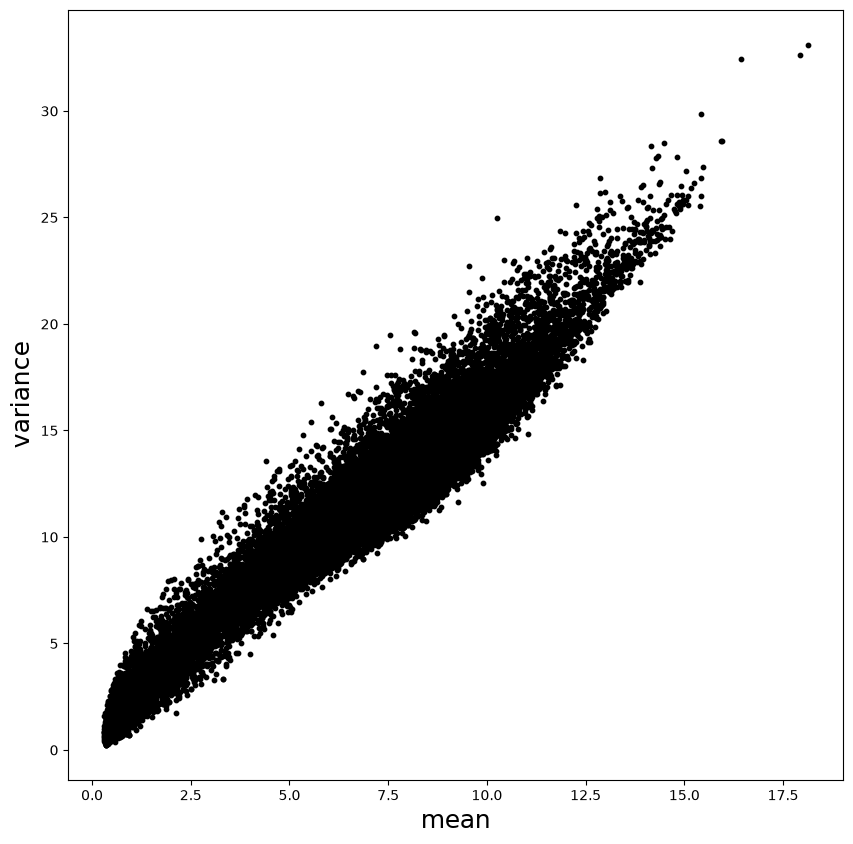

In [37]:
# plot log2 var x log2 mean
fig, ax = plt.subplots(figsize=(10,10))
ax.set_xlabel('mean', fontsize=18)
ax.set_ylabel('variance', fontsize=18)
plt.scatter(x=log2_means, y=log2_vars, marker='o', color='black', s=10)
plt.show()

score:  0.9322426019627582
coefs:  [1.51981714]
intercept:  1.0661253213087356


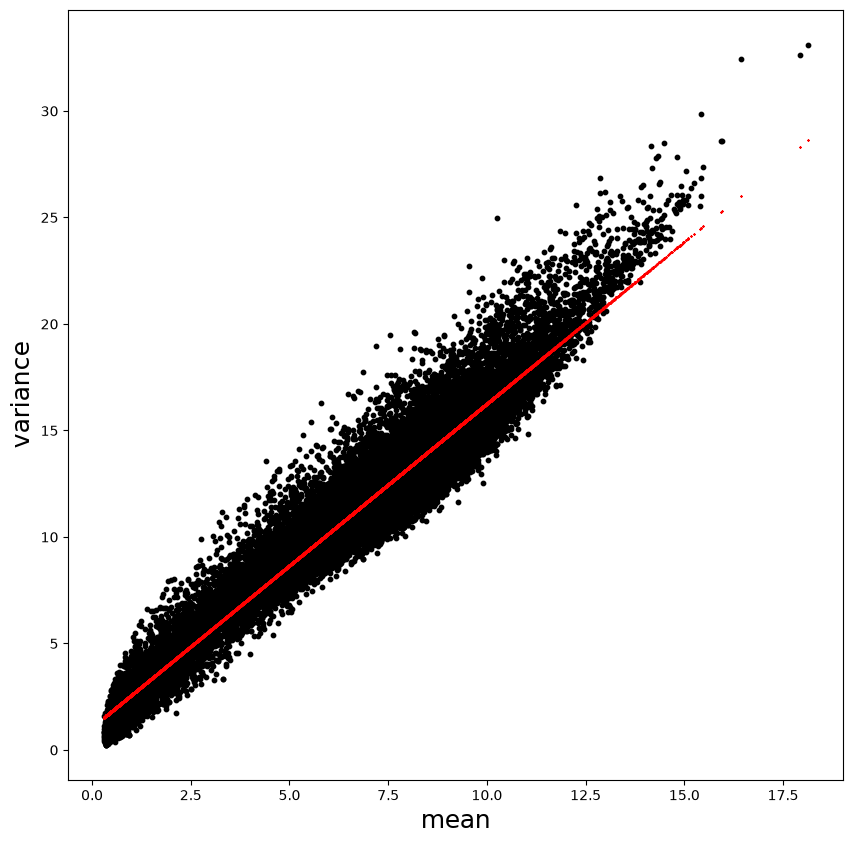

In [38]:
# fit regression line and add to plot
X = list()
for l2m in log2_means:
  X.append([l2m])

X = np.array(X)
y = np.array(log2_vars)
reg_line = LinearRegression().fit(X, y)
print('score: ', reg_line.score(X, y))
print('coefs: ', reg_line.coef_)
print('intercept: ', reg_line.intercept_)

y_pred=list()
for x in X:
  y_pred.append(reg_line.predict(x.reshape(1, -1))[0])

# now add regression line plot
fig, ax = plt.subplots(figsize=(10,10))
ax.set_xlabel('mean', fontsize=18)
ax.set_ylabel('variance', fontsize=18)
plt.scatter(x=log2_means, y=log2_vars, marker='o', color='black', s=10)
plt.scatter(x=log2_means, y=y_pred, marker='x', color='red', s=1)
plt.show()

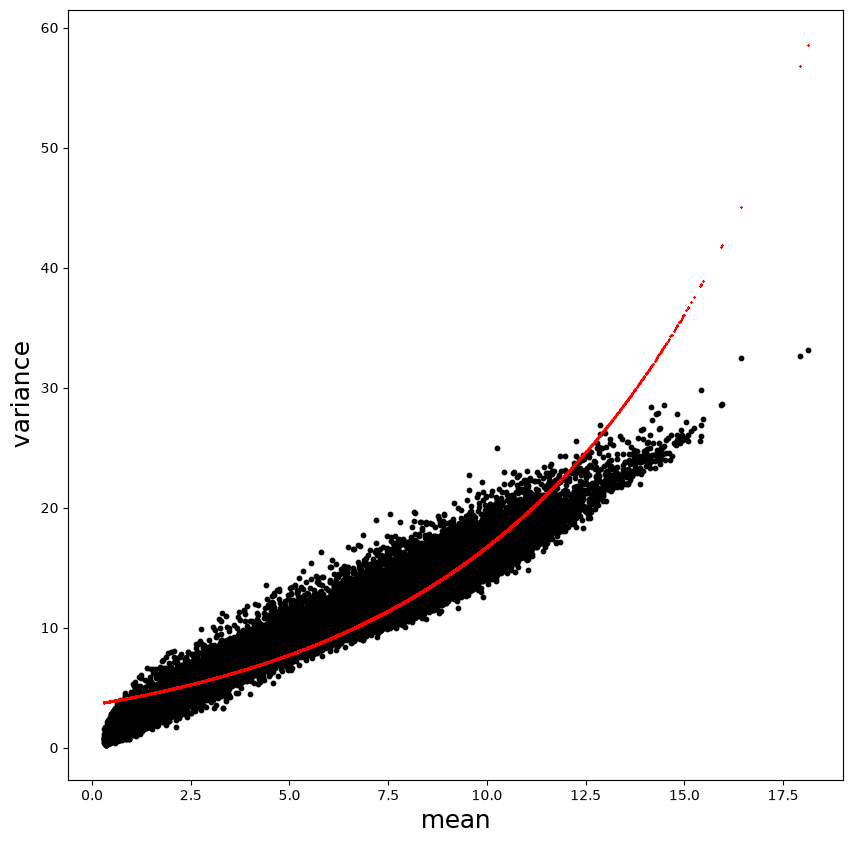

In [39]:
# use GLM to plot trend line
tweedie = TweedieRegressor(power=1, alpha=0.5, link='log')
tweedie.fit(X, y)
y_pred=list()
for x in X:
  y_pred.append(tweedie.predict(x.reshape(1, -1))[0])

fig, ax = plt.subplots(figsize=(10,10))
ax.set_xlabel('mean', fontsize=18)
ax.set_ylabel('variance', fontsize=18)
plt.scatter(x=log2_means, y=log2_vars, marker='o', color='black', s=10)
plt.scatter(x=log2_means, y=y_pred, marker='x', color='red', s=1)
plt.show()

**QUESTIONS**

1. Does the variance change as a function of the mean?

2. Which seems like a better fit -- a line or a curve?

3. Does linear regression only fit lines, not curves?

**Double click here to enter your answers to the questions above.**

1.

2.

3.

# BONUS: Use linear regression to predict the expression of one gene based on the expression of other genes.

In this exercise, we will pick one gene to be the target or response variable, and use the remaining genes to predict the value of that gene.  Because genes are parts of genetic networks and pathways (groups of genes that operate together), this exercise could reveal a pathway that is responsible for the difference between how ground control and spaceflight *Arabidopsis* roots respond to their conditions.

The gene we will pick is the one with the highest variance across all samples.

In [40]:
# get a subset of the genes which are significantly differentially expressed between
# ground control and spaceflight roots (Col-0 light contrast), with their expression values
contrast = ('Adj.p.value_(Col-0 & Ground Control & Light Treatment)'
            'v(Col-0 & Space Flight & Light Treatment)')
sig_genes = [g for g in _de_table.index[_de_table[contrast] < 0.05] if g in counts.index]
df_subset = counts.loc[sig_genes].copy()
df_subset.reset_index(inplace=True)   # gene IDs become a column named 'index'
df_subset = df_subset.rename(columns={'index': 'Unnamed: 0'})
print('DE-gene subset shape:', df_subset.shape)

DE-gene subset shape: (279, 37)


In [41]:
# find gene with highest variance
vars = list(df_subset.drop(columns=['Unnamed: 0']).var(axis=1))
index_max_var = vars.index(max(vars))
max_var_gene = df_subset.iloc[index_max_var]['Unnamed: 0']
print('max variance in gene ID: ', max_var_gene)

# convert gene ID to gene symbol
target_gene = [max_var_gene]
gene_symbol = get_symbol_from_id(target_gene)
print('max variance in gene symbol: ', gene_symbol)

max variance in gene ID:  AT2G21660
max variance in gene symbol:  ['ATGRP7|CCR2|GR-RBP7|GRP7|RBGA3|SRBP1']


In [42]:
df_subset.head()

,Unnamed: 0,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
0,AT1G01060,617.440717,705.549092,634.669145,401.882409,612.499130,130.872341,436.326935,587.600534,124.338198,...,15.868129,98.722797,1.269841,75.355323,103.351035,110.425236,48.519396,193.435432,123.660872,615.237078
1,AT1G03230,1243.152041,531.354000,1479.062691,1155.502552,1766.869565,1233.070135,935.415529,845.516902,1220.079448,...,2776.824698,1541.659260,2890.985090,2013.910810,1190.972895,1281.259610,1316.055184,1526.667985,1136.473006,992.411435
2,AT1G04750,3421.299460,5275.844204,3634.528115,4826.478314,4039.440753,3285.335731,3501.112682,3175.822965,3526.804431,...,3447.435404,3429.928618,3598.389293,3612.832030,3940.141616,3654.591106,3314.948318,3235.278564,3376.066545,4282.879465
3,AT1G05205,1106.910254,1915.497463,1004.959172,1476.935556,914.186010,927.520948,978.581037,1128.306166,1015.694022,...,872.874706,1025.089384,1439.446263,1205.091931,1242.533910,1053.699950,1160.791039,1170.896255,793.801146,1518.132450
4,AT1G06040,2034.801341,2243.945388,2557.460301,1633.912570,2943.385870,190.309906,2094.372862,2233.921816,142.826644,...,285.169435,154.048810,272.825663,68.968260,107.879776,192.119429,72.880645,464.735798,478.602317,2778.848057


You can determine the function of the highest-variance gene by searching its AGI locus ID or symbol at [TAIR](https://www.arabidopsis.org/) or [NCBI Gene](https://www.ncbi.nlm.nih.gov/gene/).  Genes that vary most strongly between spaceflight and ground control roots are frequently involved in cell wall remodeling, oxidative-stress response, or hormone (auxin) signaling - processes central to how a root senses gravity and adjusts its growth.

In [43]:
# let's standardize the data
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_subset.drop(columns=['Unnamed: 0']))

y = scaled_array[index_max_var]
X = scaled_array[0:index_max_var].T

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [44]:
# now let's build a regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](82,)","[-0.44, 0.93, 0.01,...,-1.02,-0.24,-0.16]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,15.94
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,82
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,27
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](28,)","[11.01, 6.18, 4.83,..., 0.12, 0.12, 0. ]"


In [45]:
# calculate the predictions y_pred based on the X_test subset
y_pred = model.predict(X_test)
pred = pd.DataFrame({'True_value': y_test, 'Predicted': y_pred})
pred

,True_value,Predicted
0,7.019986,8.503552
1,8.344574,7.956472
2,6.627824,8.698763
3,5.362807,8.494533
4,8.090063,7.858493
5,6.183543,6.994260
6,7.395532,8.280005
7,4.812238,4.686331


In [46]:
# print the performance metrics of the regression model
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('coefficient of determination:', model.score(X_test, y_test))

Mean Absolute Error: 1.140875077437155
Mean Squared Error: 2.2446395539423336
Root Mean Squared Error: 1.4982121191414564
coefficient of determination: -0.6566025098312305


In [47]:
# calculate the predictions y_pred_train based on the X_train subset
y_pred_train = model.predict(X_train)
pred_train = pd.DataFrame({'True_value': y_train, 'Predicted': y_pred_train})
pred_train

,True_value,Predicted
0,5.541970,5.541970
1,6.173975,6.173975
2,8.638021,8.638021
3,3.268244,3.268244
4,8.026425,8.026425
5,10.889408,10.889408
6,8.502799,8.502799
7,7.535362,7.535362
8,5.463369,5.463369
9,8.930691,8.930691


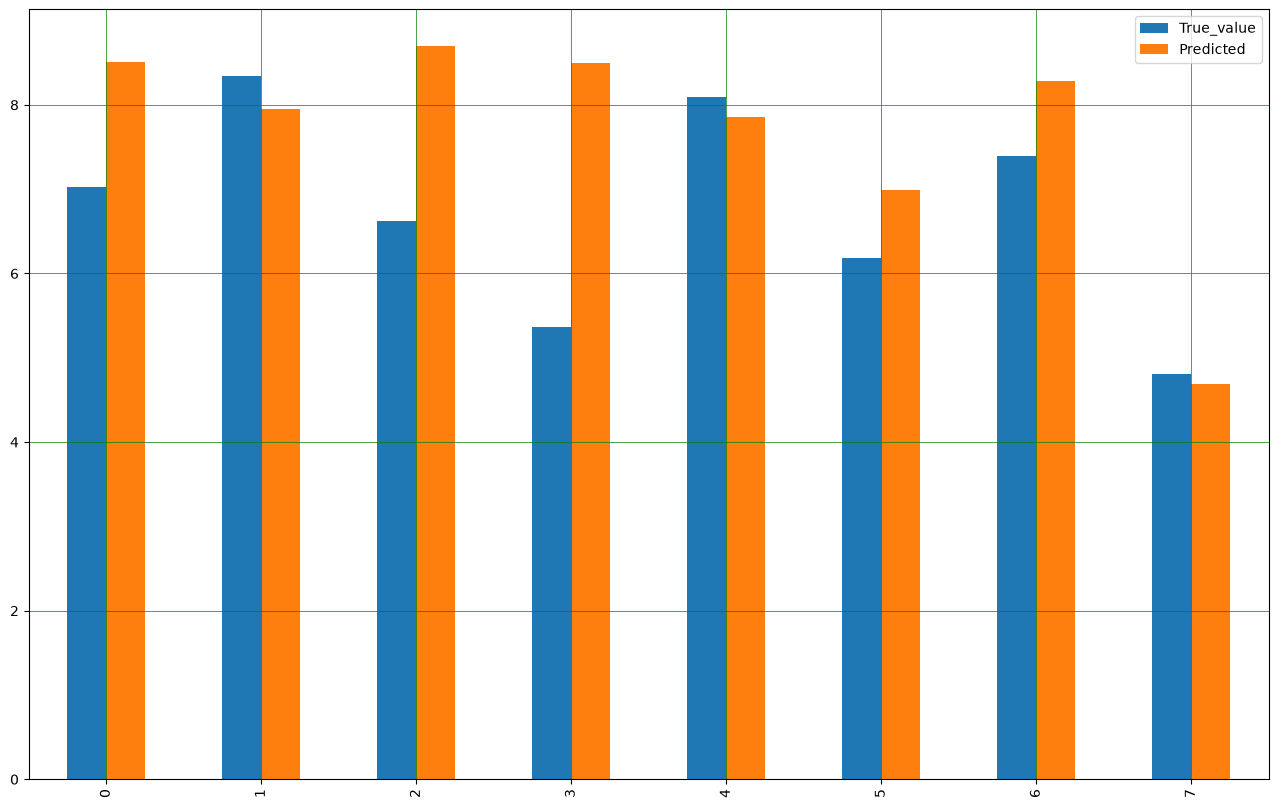

In [48]:
# we can also display the predicted vs true values graphically
pred1 = pred.head(25)
pred1.plot(kind='bar',figsize=(16,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [49]:
# find important features (top 10 largest coefficients of the regression model)
y_pred_train = model.predict(X_train)

genes_coefs_dict = dict()
genes_list = list(df_subset['Unnamed: 0'])[0:index_max_var]
coefs_list = list(model.coef_)
for i in range(len(genes_list)):
  genes_coefs_dict[genes_list[i]] = coefs_list[i]

genes_coefs_sorted_dict = {k: v for k, v in sorted(genes_coefs_dict.items(), key=lambda item: item[1], reverse=True)}

top10_genes = list(islice(genes_coefs_sorted_dict, 10))
print(top10_genes)

['AT1G15270', 'AT1G24320', 'AT1G22770', 'AT2G03870', 'AT1G64750', 'AT1G54100', 'AT1G12400', 'AT1G03230', 'AT1G06515', 'AT1G62440']


In [50]:
# print the gene symbol (name) associated with each gene id in the top 10 most important genes
gene_symbols = get_symbol_from_id(top10_genes)
print(gene_symbols)

[nan, nan, 'FB|GI', 'EMB2816|LSM7', 'ATDSS1(I)|DSS1(I)', 'ALDH7B4', nan, 'SAP1', 'ssSPTa', 'LRX2']


Looking up these 10 genes (together with the highest-variance target gene) in a functional-enrichment tool, the most strongly enriched categories tend to involve cell wall organization, oxidative-stress response, and root growth - again consistent with the way *Arabidopsis* roots remodel their growth program in spaceflight.